# Investigate Crawled News Data

This notebook analyzes crawled news data from JSON files to understand:

-   Data structure and schema
-   Content quality and completeness
-   Text characteristics
-   Data distribution patterns


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings

warnings.filterwarnings("ignore")

# Set plotting style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("Libraries imported successfully!")

ModuleNotFoundError: No module named 'seaborn'

## 1. Load JSON Data


In [ ]:
# Define data directory
DATA_DIR = Path("../data/json")

# Find all JSON files
json_files = sorted(DATA_DIR.glob("*.json"))
print(f"Found {len(json_files)} JSON files:")
for f in json_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  - {f.name}: {size_mb:.2f} MB")

Found 3 JSON files:
  - news_data_vifactcheck_dev.json: 4.46 MB
  - news_data_vifactcheck_test.json: 9.31 MB
  - news_data_vifactcheck_train.json: 32.42 MB


In [ ]:
# Load all JSON files
all_data = []
file_info = []

for json_file in json_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)
            if isinstance(data, list):
                for item in data:
                    item["_source_file"] = json_file.name
                all_data.extend(data)
                file_info.append({"file": json_file.name, "records": len(data)})
            else:
                print(f"Warning: {json_file.name} is not a list")
    except Exception as e:
        print(f"Error loading {json_file.name}: {e}")

print(f"\nTotal records loaded: {len(all_data)}")
print("\nRecords per file:")
for info in file_info:
    print(f"  {info['file']}: {info['records']:,} records")


Total records loaded: 6425

Records per file:
  news_data_vifactcheck_dev.json: 634 records
  news_data_vifactcheck_test.json: 1,282 records
  news_data_vifactcheck_train.json: 4,509 records


In [ ]:
# Convert to DataFrame
df = pd.DataFrame(all_data)
print(f"DataFrame shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

DataFrame shape: (6425, 8)

Column names:
['title', 'content', 'source_url', 'other_urls', 'images', 'contents', 'markdown', '_source_file']


## 2. Data Structure Analysis


In [ ]:
# Display basic info
print("=== DATAFRAME INFO ===")
df.info()

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== SAMPLE DATA ===")
df.head(2)

=== DATAFRAME INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6425 entries, 0 to 6424
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         6425 non-null   object
 1   content       6425 non-null   object
 2   source_url    6425 non-null   object
 3   other_urls    6425 non-null   object
 4   images        6425 non-null   object
 5   contents      6425 non-null   object
 6   markdown      6425 non-null   object
 7   _source_file  6425 non-null   object
dtypes: object(8)
memory usage: 401.7+ KB

=== DATA TYPES ===
title           object
content         object
source_url      object
other_urls      object
images          object
contents        object
markdown        object
_source_file    object
dtype: object

=== SAMPLE DATA ===


,title,content,source_url,other_urls,images,contents,markdown,_source_file
0,Khách sạn lâu đời nhất cố đô Huế tròn 122 tuổi,Khách sạn có 4 mặt tiền thuộc các giao lộ Lê L...,https://thanhnien.vn/khach-san-lau-doi-nhat-co...,"[https://thanhnien.vn/rss.html, https://thanhn...",[{'folder_path': 'jpg/thanh_nien/thanh_nien_11...,[Khách sạn có 4 mặt tiền thuộc các giao lộ Lê ...,,news_data_vifactcheck_dev.json
1,"Phát huy giá trị báo, tạp chí của Đảng trong t...","Sáng 10/4, tại TPHCM, Báo Nhân dân, Tạp chí Cộ...",https://baochinhphu.vn/phat-huy-gia-tri-bao-ta...,[],[{'folder_path': 'jpg/bao_chinh_phu/bao_chinh_...,"[Sáng 10/4, tại TPHCM, Báo Nhân dân, Tạp chí C...",,news_data_vifactcheck_dev.json


In [ ]:
# Check for missing values
missing_stats = pd.DataFrame(
    {
        "column": df.columns,
        "missing_count": df.isnull().sum(),
        "missing_pct": (df.isnull().sum() / len(df) * 100).round(2),
        "dtype": df.dtypes,
    }
)

print("=== MISSING VALUES ===")
print(missing_stats.sort_values("missing_pct", ascending=False))

=== MISSING VALUES ===
                    column  missing_count  missing_pct   dtype
title                title              0          0.0  object
content            content              0          0.0  object
source_url      source_url              0          0.0  object
other_urls      other_urls              0          0.0  object
images              images              0          0.0  object
contents          contents              0          0.0  object
markdown          markdown              0          0.0  object
_source_file  _source_file              0          0.0  object


In [ ]:
# Analyze non-scalar columns (lists, dicts)
print("=== COMPLEX COLUMN ANALYSIS ===")
for col in df.columns:
    if col == "_source_file":
        continue
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
    if sample is not None:
        col_type = type(sample).__name__
        if col_type == "list":
            lengths = (
                df[col].dropna().apply(lambda x: len(x) if isinstance(x, list) else 0)
            )
            print(f"\n{col}: list")
            print(f"  - Average length: {lengths.mean():.1f}")
            print(f"  - Max length: {lengths.max()}")
            print(f"  - Min length: {lengths.min()}")
        elif col_type == "dict":
            print(f"\n{col}: dict")
            if not df[col].dropna().empty:
                keys = set()
                for d in df[col].dropna().head(100):
                    if isinstance(d, dict):
                        keys.update(d.keys())
                print(f"  - Keys: {sorted(keys)}")

=== COMPLEX COLUMN ANALYSIS ===

other_urls: list
  - Average length: 10.1
  - Max length: 89
  - Min length: 0

images: list
  - Average length: 2.4
  - Max length: 23
  - Min length: 0

contents: list
  - Average length: 7.6
  - Max length: 52
  - Min length: 0


## 3. Content Analysis


In [ ]:
# Text length statistics for content field
if "content" in df.columns:
    df["content_length"] = df["content"].fillna("").astype(str).apply(len)
    df["content_word_count"] = (
        df["content"].fillna("").astype(str).apply(lambda x: len(x.split()))
    )

    print("=== CONTENT TEXT STATISTICS ===")
    print("Content character length:")
    print(df["content_length"].describe())
    print("\nContent word count:")
    print(df["content_word_count"].describe())
else:
    print("'content' column not found")

=== CONTENT TEXT STATISTICS ===
Content character length:
count     6425.000000
mean      1928.439844
std       2015.769323
min          0.000000
25%          0.000000
50%       1624.000000
75%       3097.000000
max      15199.000000
Name: content_length, dtype: float64

Content word count:
count    6425.000000
mean      419.191128
std       438.653424
min         0.000000
25%         0.000000
50%       353.000000
75%       674.000000
max      3284.000000
Name: content_word_count, dtype: float64


In [ ]:
# Title length statistics
if "title" in df.columns:
    df["title_length"] = df["title"].fillna("").astype(str).apply(len)
    df["title_word_count"] = (
        df["title"].fillna("").astype(str).apply(lambda x: len(x.split()))
    )

    print("=== TITLE STATISTICS ===")
    print("Title character length:")
    print(df["title_length"].describe())
    print("\nTitle word count:")
    print(df["title_word_count"].describe())
else:
    print("'title' column not found")

=== TITLE STATISTICS ===
Title character length:
count    6425.000000
mean       44.888249
std        29.289681
min         0.000000
25%         0.000000
50%        54.000000
75%        66.000000
max       135.000000
Name: title_length, dtype: float64

Title word count:
count    6425.000000
mean       10.043580
std         6.557531
min         0.000000
25%         0.000000
50%        12.000000
75%        15.000000
max        28.000000
Name: title_word_count, dtype: float64


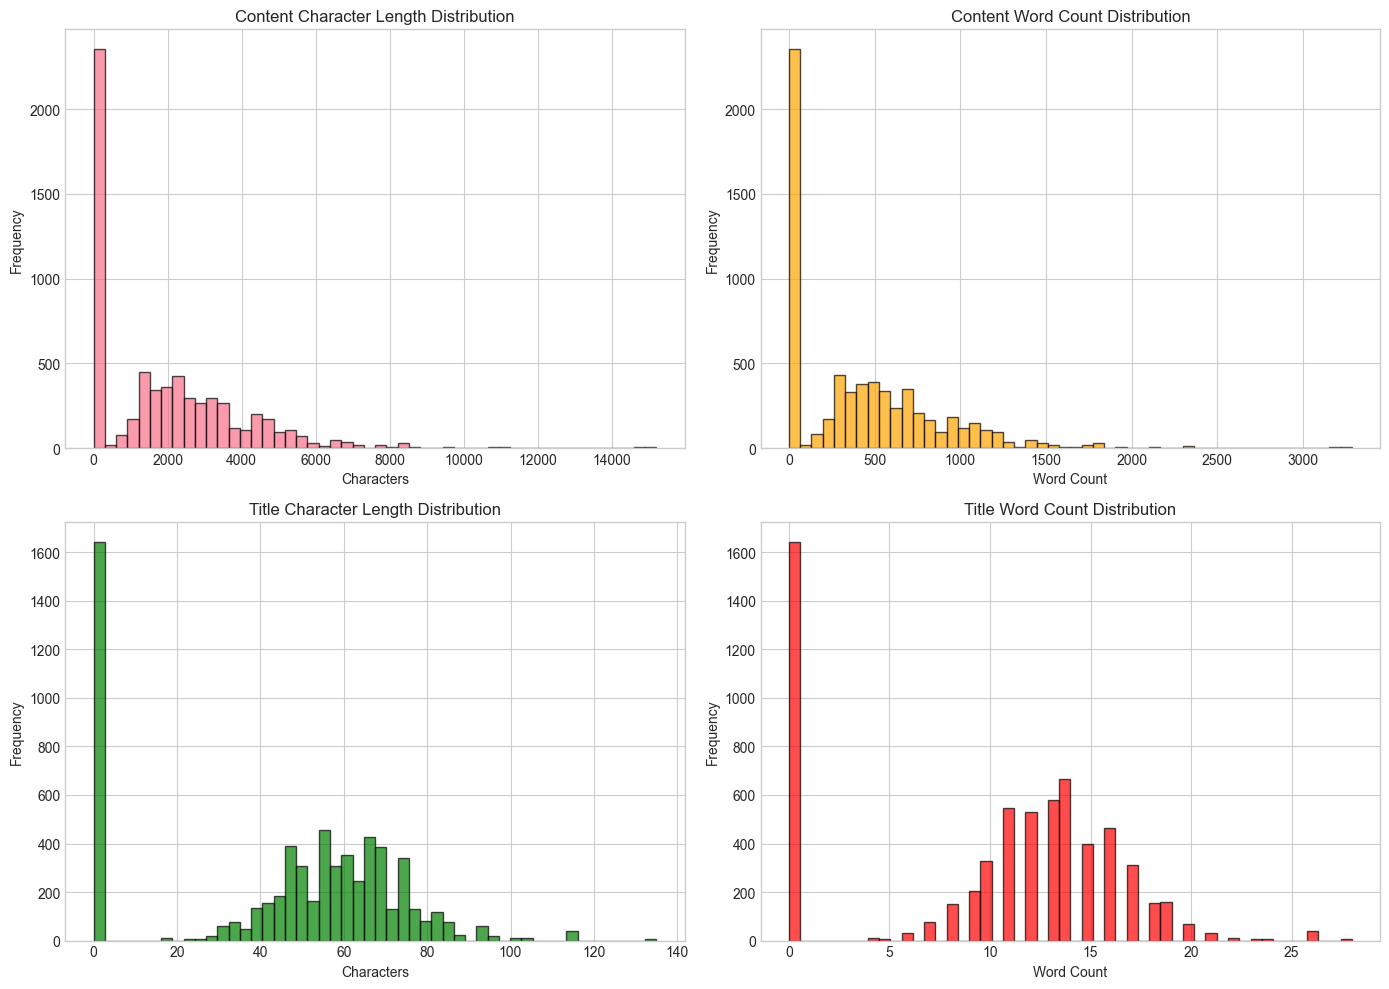

In [ ]:
# Create text length visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if "content_length" in df.columns:
    axes[0, 0].hist(df["content_length"], bins=50, edgecolor="black", alpha=0.7)
    axes[0, 0].set_title("Content Character Length Distribution")
    axes[0, 0].set_xlabel("Characters")
    axes[0, 0].set_ylabel("Frequency")

    axes[0, 1].hist(
        df["content_word_count"], bins=50, edgecolor="black", alpha=0.7, color="orange"
    )
    axes[0, 1].set_title("Content Word Count Distribution")
    axes[0, 1].set_xlabel("Word Count")
    axes[0, 1].set_ylabel("Frequency")

if "title_length" in df.columns:
    axes[1, 0].hist(
        df["title_length"], bins=50, edgecolor="black", alpha=0.7, color="green"
    )
    axes[1, 0].set_title("Title Character Length Distribution")
    axes[1, 0].set_xlabel("Characters")
    axes[1, 0].set_ylabel("Frequency")

    axes[1, 1].hist(
        df["title_word_count"], bins=50, edgecolor="black", alpha=0.7, color="red"
    )
    axes[1, 1].set_title("Title Word Count Distribution")
    axes[1, 1].set_xlabel("Word Count")
    axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Source and URL Analysis


=== SOURCE FILE DISTRIBUTION ===
_source_file
news_data_vifactcheck_train.json    4509
news_data_vifactcheck_test.json     1282
news_data_vifactcheck_dev.json       634
Name: count, dtype: int64


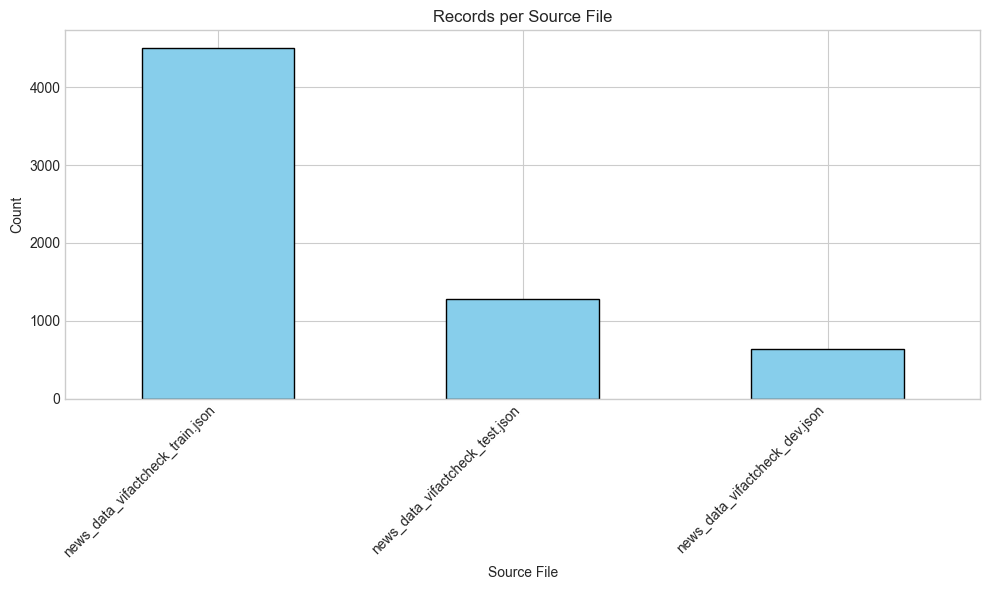

In [ ]:
# Source file distribution
if "_source_file" in df.columns:
    print("=== SOURCE FILE DISTRIBUTION ===")
    source_counts = df["_source_file"].value_counts()
    print(source_counts)

    # Visualize
    plt.figure(figsize=(10, 6))
    source_counts.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title("Records per Source File")
    plt.xlabel("Source File")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

=== SOURCE DOMAIN DISTRIBUTION ===
source_domain
baochinhphu.vn    1222
thanhnien.vn       928
dantri.com.vn      864
plo.vn             807
nld.com.vn         804
tuoitre.vn         703
tienphong.vn       597
vnexpress.net      500
Name: count, dtype: int64


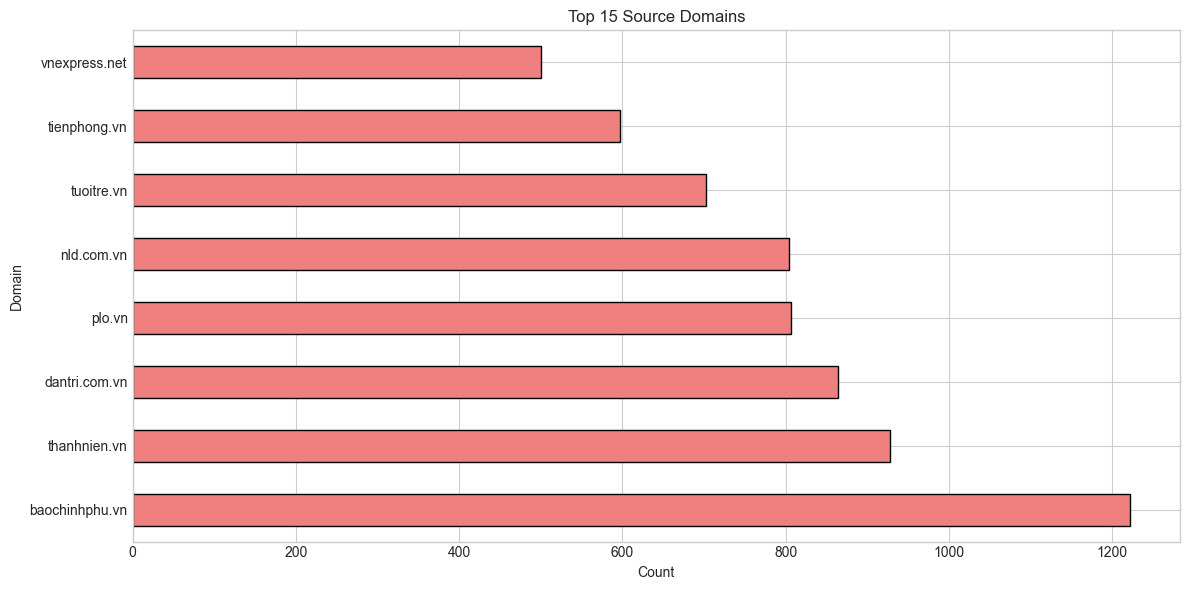

In [ ]:
# Source URL analysis
if "source_url" in df.columns:
    # Extract domain from URL
    def extract_domain(url):
        if pd.isna(url):
            return "missing"
        try:
            from urllib.parse import urlparse

            parsed = urlparse(str(url))
            return parsed.netloc.replace("www.", "")
        except:
            return "invalid"

    df["source_domain"] = df["source_url"].apply(extract_domain)

    print("=== SOURCE DOMAIN DISTRIBUTION ===")
    domain_counts = df["source_domain"].value_counts().head(15)
    print(domain_counts)

    # Visualize top domains
    plt.figure(figsize=(12, 6))
    domain_counts.plot(kind="barh", color="lightcoral", edgecolor="black")
    plt.title("Top 15 Source Domains")
    plt.xlabel("Count")
    plt.ylabel("Domain")
    plt.tight_layout()
    plt.show()

## 5. Image Analysis


=== IMAGE STATISTICS ===
Image count distribution:
count    6425.000000
mean        2.404514
std         3.502705
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        23.000000
Name: image_count, dtype: float64

Image count value counts:
image_count
0     1807
1     2121
2      943
3      378
4      202
5      138
6      126
7       19
8       20
9      124
10     145
11     123
12      60
13      90
14      37
15      80
16       6
23       6
Name: count, dtype: int64


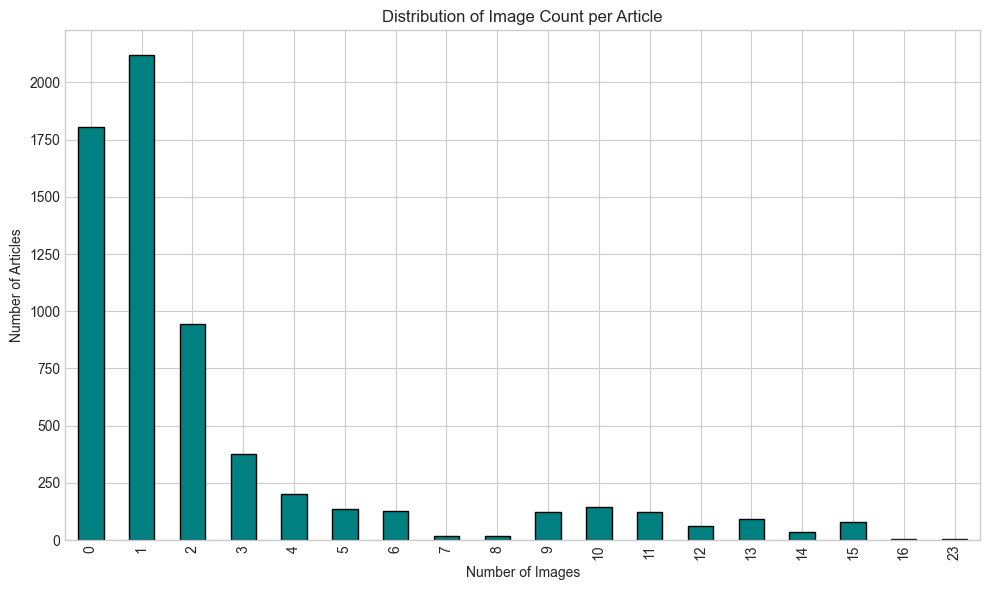

In [ ]:
# Images analysis
if "images" in df.columns:
    df["image_count"] = df["images"].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )

    print("=== IMAGE STATISTICS ===")
    print("Image count distribution:")
    print(df["image_count"].describe())
    print("\nImage count value counts:")
    print(df["image_count"].value_counts().sort_index())

    # Visualize
    plt.figure(figsize=(10, 6))
    df["image_count"].value_counts().sort_index().plot(
        kind="bar", color="teal", edgecolor="black"
    )
    plt.title("Distribution of Image Count per Article")
    plt.xlabel("Number of Images")
    plt.ylabel("Number of Articles")
    plt.tight_layout()
    plt.show()
else:
    print("'images' column not found")

## 6. Data Quality Summary


In [ ]:
# Comprehensive data quality report
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

print(f"\nTotal Records: {len(df):,}")
print(
    f"Source Files: {df['_source_file'].nunique() if '_source_file' in df.columns else 'N/A'}"
)

print("\n--- Missing Data ---")
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    for col in missing_cols:
        pct = df[col].isnull().sum() / len(df) * 100
        print(f"  {col}: {pct:.1f}% missing")
else:
    print("  No missing values found")

print("\n--- Empty Strings ---")
for col in df.select_dtypes(include=["object"]).columns:
    if col not in ["_source_file", "source_domain"]:
        empty_count = (df[col] == "").sum()
        if empty_count > 0:
            pct = empty_count / len(df) * 100
            print(f"  {col}: {empty_count:,} ({pct:.1f}%) empty")

print("\n--- Duplicates ---")
if "source_url" in df.columns:
    dup_urls = df["source_url"].duplicated().sum()
    print(f"  Duplicate URLs: {dup_urls:,}")
if "title" in df.columns:
    dup_titles = df["title"].duplicated().sum()
    print(f"  Duplicate Titles: {dup_titles:,}")

print("\n--- Content Statistics ---")
if "content_length" in df.columns:
    print(f"  Avg content length: {df['content_length'].mean():.0f} chars")
    print(f"  Avg word count: {df['content_word_count'].mean():.0f} words")
    short_content = (df["content_length"] < 100).sum()
    print(
        f"  Very short content (<100 chars): {short_content:,} ({short_content/len(df)*100:.1f}%)"
    )

if "image_count" in df.columns:
    no_images = (df["image_count"] == 0).sum()
    print(f"  Articles without images: {no_images:,} ({no_images/len(df)*100:.1f}%)")

DATA QUALITY SUMMARY

Total Records: 6,425
Source Files: 3

--- Missing Data ---
  No missing values found

--- Empty Strings ---
  title: 1,643 (25.6%) empty
  content: 2,322 (36.1%) empty
  markdown: 6,425 (100.0%) empty

--- Duplicates ---
  Duplicate URLs: 5,502
  Duplicate Titles: 5,751

--- Content Statistics ---
  Avg content length: 1928 chars
  Avg word count: 419 words
  Very short content (<100 chars): 2,322 (36.1%)
  Articles without images: 1,807 (28.1%)


## 7. Sample Data Preview


In [ ]:
# Show sample records with key fields
display_cols = ["title", "content", "source_url", "_source_file"]
available_cols = [c for c in display_cols if c in df.columns]

print("=== SAMPLE RECORDS ===")
for i, (idx, row) in enumerate(df[available_cols].head(3).iterrows()):
    print(f"\n--- Record {i+1} ---")
    for col in available_cols:
        value = row[col]
        if col == "content" and isinstance(value, str):
            value = value[:200] + "..." if len(value) > 200 else value
        print(f"{col}: {value}")
    print("-" * 40)

=== SAMPLE RECORDS ===

--- Record 1 ---
title: Khách sạn lâu đời nhất cố đô Huế tròn 122 tuổi
content: Khách sạn có 4 mặt tiền thuộc các giao lộ Lê Lợi - Hùng Vương, Hoàng Hoa Thám - Trương Định (TP.Huế, Thừa Thiên-Huế) bên cạnh cầu Trường Tiền với "view" sông Hương thơ mộng,
Khách sạn ra đời vào năm 1...
source_url: https://thanhnien.vn/khach-san-lau-doi-nhat-co-do-hue-tron-122-tuoi-185230327161030989.htm
_source_file: news_data_vifactcheck_dev.json
----------------------------------------

--- Record 2 ---
title: Phát huy giá trị báo, tạp chí của Đảng trong thời đại bùng nổ thông tin
content: Sáng 10/4, tại TPHCM, Báo Nhân dân, Tạp chí Cộng sản phối hợp với Thành ủy TPHCM và Tổng công ty Bưu điện Việt Nam tổ chức Hội nghị tiếp tục thực hiện Chỉ thị số 11 của Bộ Chính trị về tích cực đổi mớ...
source_url: https://baochinhphu.vn/phat-huy-gia-tri-bao-tap-chi-cua-dang-trong-thoi-dai-bung-no-thong-tin-102230410135707719.htm
_source_file: news_data_vifactcheck_dev.json
-------------------

## Export Summary (Optional)

Save the analysis results to a file for reference.


In [ ]:
# Save summary to CSV (optional)
# summary_df = df[['title', 'content_length', 'content_word_count', 'source_domain', 'image_count']].copy()
# summary_df.to_csv('data_summary.csv', index=False)
# print("Summary saved to data_summary.csv")